In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Volve production data.xlsx", sheet_name="Daily Production Data")

df.head()

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


In [2]:
print("Shape:", df.shape)

Shape: (15634, 24)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15634 entries, 0 to 15633
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   DATEPRD                   15634 non-null  datetime64[ns]
 1   WELL_BORE_CODE            15634 non-null  object        
 2   NPD_WELL_BORE_CODE        15634 non-null  int64         
 3   NPD_WELL_BORE_NAME        15634 non-null  object        
 4   NPD_FIELD_CODE            15634 non-null  int64         
 5   NPD_FIELD_NAME            15634 non-null  object        
 6   NPD_FACILITY_CODE         15634 non-null  int64         
 7   NPD_FACILITY_NAME         15634 non-null  object        
 8   ON_STREAM_HRS             15349 non-null  float64       
 9   AVG_DOWNHOLE_PRESSURE     8980 non-null   float64       
 10  AVG_DOWNHOLE_TEMPERATURE  8980 non-null   float64       
 11  AVG_DP_TUBING             8980 non-null   float64       
 12  AVG_ANNULUS_PRESS 

In [4]:
df.describe()

,DATEPRD,NPD_WELL_BORE_CODE,NPD_FIELD_CODE,NPD_FACILITY_CODE,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL
count,15634,15634.000000,15634.0,15634.0,15349.000000,8980.000000,8980.000000,8980.000000,7890.000000,8919.000000,9155.000000,9146.000000,15340.000000,9161.000000,9161.000000,9161.000000,5706.000000
mean,2012-11-07 17:39:58.004349440,5908.581745,3420717.0,369304.0,19.994093,181.803869,77.162969,154.028787,14.856100,55.168533,45.377811,67.728440,11.441060,1095.631548,161049.059703,1672.151332,5315.480815
min,2007-09-01 00:00:00,5351.000000,3420717.0,369304.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-457.840000,0.000000
25%,2010-07-30 00:00:00,5599.000000,3420717.0,369304.0,24.000000,0.000000,0.000000,83.665361,10.841437,18.952989,31.148062,56.577834,0.000000,190.690000,29430.590000,19.870000,4338.204674
50%,2013-05-08 00:00:00,5693.000000,3420717.0,369304.0,24.000000,232.896939,103.186689,175.588861,16.308598,52.096877,37.933620,80.071250,2.384969,557.550000,87749.660000,1097.790000,5504.739769
75%,2015-02-19 00:00:00,5769.000000,3420717.0,369304.0,24.000000,255.401455,106.276591,204.319964,21.306125,99.924288,57.101268,88.062202,13.765020,1345.200000,202482.300000,3260.950000,6781.058040
max,2016-12-01 00:00:00,7405.000000,3420717.0,369304.0,25.000000,397.588550,108.502178,345.906770,30.019828,100.000000,137.311030,93.509584,125.718570,5901.840000,851131.520000,8019.740000,10013.600000
std,NaN,649.231622,0.0,0.0,8.369978,109.712363,45.657948,76.752373,8.406822,36.692924,24.752631,27.719028,19.816928,1323.538151,188136.410434,1706.982853,2181.486695


In [5]:
df.columns.tolist()

['DATEPRD',
 'WELL_BORE_CODE',
 'NPD_WELL_BORE_CODE',
 'NPD_WELL_BORE_NAME',
 'NPD_FIELD_CODE',
 'NPD_FIELD_NAME',
 'NPD_FACILITY_CODE',
 'NPD_FACILITY_NAME',
 'ON_STREAM_HRS',
 'AVG_DOWNHOLE_PRESSURE',
 'AVG_DOWNHOLE_TEMPERATURE',
 'AVG_DP_TUBING',
 'AVG_ANNULUS_PRESS',
 'AVG_CHOKE_SIZE_P',
 'AVG_CHOKE_UOM',
 'AVG_WHP_P',
 'AVG_WHT_P',
 'DP_CHOKE_SIZE',
 'BORE_OIL_VOL',
 'BORE_GAS_VOL',
 'BORE_WAT_VOL',
 'BORE_WI_VOL',
 'FLOW_KIND',
 'WELL_TYPE']

In [6]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

BORE_WI_VOL                 9928
AVG_ANNULUS_PRESS           7744
AVG_CHOKE_SIZE_P            6715
AVG_DP_TUBING               6654
AVG_DOWNHOLE_TEMPERATURE    6654
AVG_DOWNHOLE_PRESSURE       6654
AVG_WHT_P                   6488
AVG_WHP_P                   6479
BORE_GAS_VOL                6473
AVG_CHOKE_UOM               6473
BORE_WAT_VOL                6473
BORE_OIL_VOL                6473
DP_CHOKE_SIZE                294
ON_STREAM_HRS                285
dtype: int64

In [7]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": missing_percent
})

missing_table[missing_table["Missing Values"] > 0].sort_values(
    "Missing %",
    ascending=False
)

,Missing Values,Missing %
BORE_WI_VOL,9928,63.502622
AVG_ANNULUS_PRESS,7744,49.533069
AVG_CHOKE_SIZE_P,6715,42.951260
AVG_DP_TUBING,6654,42.561085
AVG_DOWNHOLE_TEMPERATURE,6654,42.561085
AVG_DOWNHOLE_PRESSURE,6654,42.561085
AVG_WHT_P,6488,41.499296
AVG_WHP_P,6479,41.441730
BORE_GAS_VOL,6473,41.403352
AVG_CHOKE_UOM,6473,41.403352


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print(df["DATEPRD"].head())
print(df["DATEPRD"].dtype)

0   2014-04-07
1   2014-04-08
2   2014-04-09
3   2014-04-10
4   2014-04-11
Name: DATEPRD, dtype: datetime64[ns]
datetime64[ns]


In [10]:
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

print("Start date:", df["DATEPRD"].min())
print("End date:", df["DATEPRD"].max())

Start date: 2007-09-01 00:00:00
End date: 2016-12-01 00:00:00


In [11]:
df.groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"].apply(
    lambda x: x.isna().sum()
).sort_values(ascending=False)

NPD_WELL_BORE_NAME
15/9-F-4       3327
15/9-F-5       3146
15/9-F-1 C        0
15/9-F-12         0
15/9-F-11         0
15/9-F-15 D       0
15/9-F-14         0
Name: BORE_OIL_VOL, dtype: int64

In [12]:
well_missing = df.groupby("NPD_WELL_BORE_NAME").agg(
    Total_Records=("BORE_OIL_VOL", "size"),
    Missing_Oil=("BORE_OIL_VOL", lambda x: x.isna().sum())
)

well_missing["Missing_Oil_%"] = (
    well_missing["Missing_Oil"] /
    well_missing["Total_Records"] * 100
)

well_missing.sort_values("Missing_Oil_%", ascending=False)

,Total_Records,Missing_Oil,Missing_Oil_%
NPD_WELL_BORE_NAME,,,
15/9-F-4,3327,3327,100.000000
15/9-F-5,3306,3146,95.160315
15/9-F-1 C,746,0,0.000000
15/9-F-12,3056,0,0.000000
15/9-F-11,1165,0,0.000000
15/9-F-15 D,978,0,0.000000
15/9-F-14,3056,0,0.000000


In [13]:
df.columns

Index(['DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME',
       'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE',
       'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE',
       'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS',
       'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'AVG_WHP_P', 'AVG_WHT_P',
       'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL',
       'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE'],
      dtype='object')

In [14]:
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])

In [15]:
df["DATEPRD"].min(), df["DATEPRD"].max()

(Timestamp('2007-09-01 00:00:00'), Timestamp('2016-12-01 00:00:00'))

In [16]:
missing_oil_wells = df[
    df["NPD_WELL_BORE_NAME"].isin(["15/9-F-4", "15/9-F-5"])
]

missing_oil_wells[
    ["DATEPRD", "NPD_WELL_BORE_NAME", "BORE_OIL_VOL"]
].sort_values(
    ["NPD_WELL_BORE_NAME", "DATEPRD"]
)

,DATEPRD,NPD_WELL_BORE_NAME,BORE_OIL_VOL
9001,2007-09-01,15/9-F-4,NaN
9002,2007-09-02,15/9-F-4,NaN
9003,2007-09-03,15/9-F-4,NaN
9004,2007-09-04,15/9-F-4,NaN
9005,2007-09-05,15/9-F-4,NaN
...,...,...,...
15629,2016-09-14,15/9-F-5,0.0
15630,2016-09-15,15/9-F-5,0.0
15631,2016-09-16,15/9-F-5,0.0
15632,2016-09-17,15/9-F-5,0.0


In [17]:
missing_oil_wells["YEAR"] = missing_oil_wells["DATEPRD"].dt.year

yearly_missing = missing_oil_wells.groupby(
    ["NPD_WELL_BORE_NAME", "YEAR"]
).agg(
    Total_Records=("BORE_OIL_VOL", "size"),
    Missing_Oil=("BORE_OIL_VOL", lambda x: x.isna().sum())
)

yearly_missing["Missing_Oil_%"] = (
    yearly_missing["Missing_Oil"] /
    yearly_missing["Total_Records"] * 100
)

yearly_missing

C:\Users\kirit\AppData\Local\Temp\ipykernel_5496\1587941203.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_oil_wells["YEAR"] = missing_oil_wells["DATEPRD"].dt.year


Total_Records  Missing_Oil  Missing_Oil_%
NPD_WELL_BORE_NAME YEAR                                           
15/9-F-4           2007            122          122     100.000000
                   2008            366          366     100.000000
                   2009            365          365     100.000000
                   2010            365          365     100.000000
                   2011            365          365     100.000000
                   2012            366          366     100.000000
                   2013            365          365     100.000000
                   2014            365          365     100.000000
                   2015            365          365     100.000000
                   2016            283          283     100.000000
15/9-F-5           2007            122          122     100.000000
                   2008            366          366     100.000000
                   2009            365          365     100.000000
                   2010            365          365     100.000000
                   2011            365          365     100.000000
                   2012            366          366     100.000000
                   2013            365          365     100.000000
                   2014            365          365     100.000000
                   2015            365          365     100.000000
                   2016            262          102      38.931298

In [18]:
df.groupby("NPD_WELL_BORE_NAME")[
    ["FLOW_KIND", "WELL_TYPE"]
].agg(lambda x: x.dropna().unique())

,FLOW_KIND,WELL_TYPE
NPD_WELL_BORE_NAME,,
15/9-F-1 C,[production],"[WI, OP]"
15/9-F-11,[production],[OP]
15/9-F-12,[production],[OP]
15/9-F-14,[production],[OP]
15/9-F-15 D,[production],[OP]
15/9-F-4,[injection],[WI]
15/9-F-5,"[injection, production]","[WI, OP]"


In [19]:
f5 = df[df["NPD_WELL_BORE_NAME"] == "15/9-F-5"].copy()

f5.groupby(["FLOW_KIND", f5["DATEPRD"].dt.year])["BORE_OIL_VOL"].agg(
    Total_Records="size",
    Missing_Oil=lambda x: x.isna().sum()
)

Total_Records  Missing_Oil
FLOW_KIND  DATEPRD                            
injection  2007               122          122
           2008               366          366
           2009               365          365
           2010               365          365
           2011               365          365
           2012               366          366
           2013               365          365
           2014               365          365
           2015               365          365
           2016               102          102
production 2016               160            0

In [20]:
df.loc[
    df["BORE_OIL_VOL"].isna(),
    "FLOW_KIND"
].value_counts(dropna=False)

FLOW_KIND
injection    6473
Name: count, dtype: int64

In [21]:
df_clean = df.copy()

df_clean.loc[
    (df_clean["FLOW_KIND"] == "injection") &
    (df_clean["BORE_OIL_VOL"].isna()),
    "BORE_OIL_VOL"
] = 0

In [22]:
df_clean["BORE_OIL_VOL"].isna().sum()

np.int64(0)

In [23]:
df.loc[
    df["BORE_GAS_VOL"].isna(),
    "FLOW_KIND"
].value_counts(dropna=False)

FLOW_KIND
injection    6473
Name: count, dtype: int64

In [24]:
df.loc[
    df["BORE_WAT_VOL"].isna(),
    "FLOW_KIND"
].value_counts(dropna=False)

FLOW_KIND
injection    6473
Name: count, dtype: int64

In [25]:
df_clean = df.copy()

for col in ["BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL"]:
    df_clean.loc[
        (df_clean["FLOW_KIND"] == "injection") &
        (df_clean[col].isna()),
        col
    ] = 0

In [26]:
df_clean[["BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL"]].isna().sum()

BORE_OIL_VOL    0
BORE_GAS_VOL    0
BORE_WAT_VOL    0
dtype: int64

In [27]:
df.loc[
    df["AVG_CHOKE_UOM"].isna(),
    "FLOW_KIND"
].value_counts(dropna=False)

FLOW_KIND
injection    6473
Name: count, dtype: int64

In [28]:
df_clean.loc[
    (df_clean["FLOW_KIND"] == "injection") &
    (df_clean["AVG_CHOKE_UOM"].isna()),
    "AVG_CHOKE_UOM"
] = "N/A"

In [29]:
df.groupby("FLOW_KIND")[
    [
        "AVG_DP_TUBING",
        "AVG_DOWNHOLE_TEMPERATURE",
        "AVG_DOWNHOLE_PRESSURE",
        "AVG_WHP_P",
        "AVG_WHT_P"
    ]
].apply(lambda x: x.isna().sum())

,AVG_DP_TUBING,AVG_DOWNHOLE_TEMPERATURE,AVG_DOWNHOLE_PRESSURE,AVG_WHP_P,AVG_WHT_P
FLOW_KIND,,,,,
injection,6473,6473,6473,6473,6473
production,181,181,181,6,15


In [30]:
df[df["FLOW_KIND"] == "production"][
    [
        "AVG_DP_TUBING",
        "AVG_DOWNHOLE_TEMPERATURE",
        "AVG_DOWNHOLE_PRESSURE",
        "AVG_WHP_P",
        "AVG_WHT_P"
    ]
].isna().sum()

AVG_DP_TUBING               181
AVG_DOWNHOLE_TEMPERATURE    181
AVG_DOWNHOLE_PRESSURE       181
AVG_WHP_P                     6
AVG_WHT_P                    15
dtype: int64

In [31]:
df[df["FLOW_KIND"] == "production"].groupby(
    "NPD_WELL_BORE_NAME"
)[
    [
        "AVG_DP_TUBING",
        "AVG_DOWNHOLE_TEMPERATURE",
        "AVG_DOWNHOLE_PRESSURE",
        "AVG_WHP_P",
        "AVG_WHT_P"
    ]
].apply(lambda x: x.isna().sum())

,AVG_DP_TUBING,AVG_DOWNHOLE_TEMPERATURE,AVG_DOWNHOLE_PRESSURE,AVG_WHP_P,AVG_WHT_P
NPD_WELL_BORE_NAME,,,,,
15/9-F-1 C,3,3,3,0,0
15/9-F-11,6,6,6,6,6
15/9-F-12,6,6,6,0,0
15/9-F-14,6,6,6,0,0
15/9-F-15 D,0,0,0,0,0
15/9-F-5,160,160,160,0,9


In [32]:
f5_prod = df[
    (df["NPD_WELL_BORE_NAME"] == "15/9-F-5") &
    (df["FLOW_KIND"] == "production")
]

f5_prod[
    f5_prod["AVG_DOWNHOLE_PRESSURE"].isna()
][
    ["DATEPRD", "BORE_OIL_VOL", "AVG_DOWNHOLE_PRESSURE"]
].sort_values("DATEPRD")

,DATEPRD,BORE_OIL_VOL,AVG_DOWNHOLE_PRESSURE
15473,2016-04-11,0.0,NaN
15474,2016-04-12,0.0,NaN
15475,2016-04-13,0.0,NaN
15476,2016-04-14,0.0,NaN
15477,2016-04-15,0.0,NaN
...,...,...,...
15628,2016-09-13,0.0,NaN
15629,2016-09-14,0.0,NaN
15630,2016-09-15,0.0,NaN
15631,2016-09-16,0.0,NaN


In [33]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
DATEPRD,15634,2012-11-07 17:39:58.004349440,2007-09-01 00:00:00,2010-07-30 00:00:00,2013-05-08 00:00:00,2015-02-19 00:00:00,2016-12-01 00:00:00,NaN
NPD_WELL_BORE_CODE,15634.0,5908.581745,5351.0,5599.0,5693.0,5769.0,7405.0,649.231622
NPD_FIELD_CODE,15634.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,3420717.0,0.0
NPD_FACILITY_CODE,15634.0,369304.0,369304.0,369304.0,369304.0,369304.0,369304.0,0.0
ON_STREAM_HRS,15349.0,19.994093,0.0,24.0,24.0,24.0,25.0,8.369978
AVG_DOWNHOLE_PRESSURE,8980.0,181.803869,0.0,0.0,232.896939,255.401455,397.58855,109.712363
AVG_DOWNHOLE_TEMPERATURE,8980.0,77.162969,0.0,0.0,103.186689,106.276591,108.502178,45.657948
AVG_DP_TUBING,8980.0,154.028787,0.0,83.665361,175.588861,204.319964,345.90677,76.752373
AVG_ANNULUS_PRESS,7890.0,14.8561,0.0,10.841437,16.308598,21.306125,30.019828,8.406822
AVG_CHOKE_SIZE_P,8919.0,55.168533,0.0,18.952989,52.096877,99.924288,100.0,36.692924


In [34]:
df_clean[df_clean["BORE_WAT_VOL"] < 0][
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "FLOW_KIND",
        "BORE_WAT_VOL"
    ]
]

,DATEPRD,NPD_WELL_BORE_NAME,FLOW_KIND,BORE_WAT_VOL
1982,2008-04-23,15/9-F-12,production,-14.19
3502,2012-08-13,15/9-F-12,production,-457.84
5350,2009-03-03,15/9-F-14,production,-0.95
6558,2012-08-13,15/9-F-14,production,-59.19


In [35]:
df_clean[df_clean["DATEPRD"] == "2012-08-13"][
    [
        "DATEPRD",
        "NPD_WELL_BORE_NAME",
        "FLOW_KIND",
        "BORE_OIL_VOL",
        "BORE_GAS_VOL",
        "BORE_WAT_VOL",
        "ON_STREAM_HRS"
    ]
]

,DATEPRD,NPD_WELL_BORE_NAME,FLOW_KIND,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,ON_STREAM_HRS
3502,2012-08-13,15/9-F-12,production,632.96,12123.37,-457.84,0.62500
6558,2012-08-13,15/9-F-14,production,202.53,3754.12,-59.19,0.62500
10809,2012-08-13,15/9-F-4,injection,0.00,0.00,0.00,4.45833
14136,2012-08-13,15/9-F-5,injection,0.00,0.00,0.00,21.12499


In [36]:
negative_water = df_clean[df_clean["BORE_WAT_VOL"] < 0]

negative_water[
    ["DATEPRD", "NPD_WELL_BORE_NAME", "BORE_WAT_VOL"]
]

,DATEPRD,NPD_WELL_BORE_NAME,BORE_WAT_VOL
1982,2008-04-23,15/9-F-12,-14.19
3502,2012-08-13,15/9-F-12,-457.84
5350,2009-03-03,15/9-F-14,-0.95
6558,2012-08-13,15/9-F-14,-59.19


In [37]:
df_clean["NEGATIVE_WATER_FLAG"] = (
    df_clean["BORE_WAT_VOL"] < 0
)

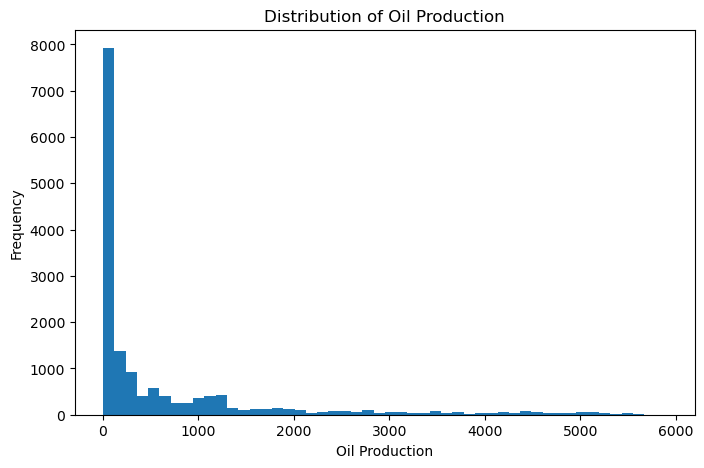

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_clean["BORE_OIL_VOL"], bins=50)
plt.xlabel("Oil Production")
plt.ylabel("Frequency")
plt.title("Distribution of Oil Production")
plt.show()

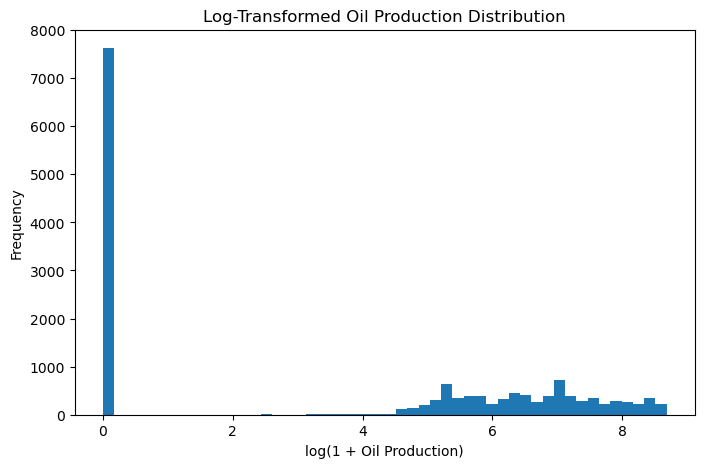

In [39]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    np.log1p(df_clean["BORE_OIL_VOL"]),
    bins=50
)

plt.xlabel("log(1 + Oil Production)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Oil Production Distribution")
plt.show()

In [40]:
zero_count = (df_clean["BORE_OIL_VOL"] == 0).sum()
positive_count = (df_clean["BORE_OIL_VOL"] > 0).sum()

print("Zero oil production:", zero_count)
print("Positive oil production:", positive_count)

print("Zero percentage:",
      round(zero_count / len(df_clean) * 100, 2), "%")

Zero oil production: 7626
Positive oil production: 8008
Zero percentage: 48.78 %


In [42]:
well_zero = df_clean.groupby("NPD_WELL_BORE_NAME").agg(
    Total_Records=("BORE_OIL_VOL", "size"),
    Zero_Oil=("BORE_OIL_VOL", lambda x: (x == 0).sum()),
    Positive_Oil=("BORE_OIL_VOL", lambda x: (x > 0).sum())
)

well_zero["Zero_Oil_%"] = (
    well_zero["Zero_Oil"] / well_zero["Total_Records"] * 100
).round(2)

well_zero.sort_values("Zero_Oil_%", ascending=False).head(15)

,Total_Records,Zero_Oil,Positive_Oil,Zero_Oil_%
NPD_WELL_BORE_NAME,,,,
15/9-F-4,3327,3327,0,100.00
15/9-F-5,3306,3177,129,96.10
15/9-F-1 C,746,316,430,42.36
15/9-F-15 D,978,211,767,21.57
15/9-F-14,3056,333,2723,10.90
15/9-F-12,3056,220,2836,7.20
15/9-F-11,1165,42,1123,3.61


In [43]:
# Check production statistics by well
well_stats = df_clean.groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"].agg(
    ["count", "min", "max", "mean", "median"]
).round(2)

well_stats

,count,min,max,mean,median
NPD_WELL_BORE_NAME,,,,,
15/9-F-1 C,746,0.0,1549.81,238.22,200.68
15/9-F-11,1165,0.0,2064.61,985.28,1077.76
15/9-F-12,3056,0.0,5901.84,1498.56,697.66
15/9-F-14,3056,0.0,5644.37,1290.00,880.78
15/9-F-15 D,978,0.0,513.12,151.86,175.33
15/9-F-4,3327,0.0,0.00,0.00,0.00
15/9-F-5,3306,0.0,396.80,12.45,0.00


In [44]:
df_clean[
    df_clean["NPD_WELL_BORE_NAME"].isin(["15/9-F-4", "15/9-F-5"])
][
    ["DATEPRD", "NPD_WELL_BORE_NAME", "BORE_OIL_VOL"]
].sort_values(
    ["NPD_WELL_BORE_NAME", "DATEPRD"]
).head(20)

,DATEPRD,NPD_WELL_BORE_NAME,BORE_OIL_VOL
9001,2007-09-01,15/9-F-4,0.0
9002,2007-09-02,15/9-F-4,0.0
9003,2007-09-03,15/9-F-4,0.0
9004,2007-09-04,15/9-F-4,0.0
9005,2007-09-05,15/9-F-4,0.0
9006,2007-09-06,15/9-F-4,0.0
9007,2007-09-07,15/9-F-4,0.0
9008,2007-09-08,15/9-F-4,0.0
9009,2007-09-09,15/9-F-4,0.0
9010,2007-09-10,15/9-F-4,0.0


In [45]:
df_clean[
    (df_clean["NPD_WELL_BORE_NAME"] == "15/9-F-5") &
    (df_clean["BORE_OIL_VOL"] > 0)
][
    ["DATEPRD", "NPD_WELL_BORE_NAME", "BORE_OIL_VOL"]
].sort_values("DATEPRD").head(20)

,DATEPRD,NPD_WELL_BORE_NAME,BORE_OIL_VOL
15482,2016-04-20,15/9-F-5,17.75
15483,2016-04-21,15/9-F-5,396.80
15484,2016-04-22,15/9-F-5,358.12
15485,2016-04-23,15/9-F-5,327.46
15486,2016-04-24,15/9-F-5,319.31
15487,2016-04-25,15/9-F-5,327.28
15488,2016-04-26,15/9-F-5,334.20
15489,2016-04-27,15/9-F-5,329.53
15490,2016-04-28,15/9-F-5,333.07
15491,2016-04-29,15/9-F-5,328.68


In [46]:
f5_positive = df_clean[
    (df_clean["NPD_WELL_BORE_NAME"] == "15/9-F-5") &
    (df_clean["BORE_OIL_VOL"] > 0)
]

print("First production date:", f5_positive["DATEPRD"].min())
print("Last production date:", f5_positive["DATEPRD"].max())
print("Positive records:", len(f5_positive))

First production date: 2016-04-20 00:00:00
Last production date: 2016-08-26 00:00:00
Positive records: 129


In [47]:
f5_positive[
    ["DATEPRD", "BORE_OIL_VOL"]
].tail(20)

,DATEPRD,BORE_OIL_VOL
15591,2016-08-07,320.54
15592,2016-08-08,319.73
15593,2016-08-09,302.45
15594,2016-08-10,315.74
15595,2016-08-11,321.91
15596,2016-08-12,329.87
15597,2016-08-13,330.59
15598,2016-08-14,342.05
15599,2016-08-15,351.68
15600,2016-08-16,360.71


In [48]:
oil_positive = df_clean.loc[
    df_clean["BORE_OIL_VOL"] > 0,
    "BORE_OIL_VOL"
]

print(oil_positive.describe())

count    8008.000000
mean     1253.381695
std      1343.971024
min         0.170000
25%       271.960000
50%       715.895000
75%      1651.532500
max      5901.840000
Name: BORE_OIL_VOL, dtype: float64


In [49]:
Q1 = oil_positive.quantile(0.25)
Q3 = oil_positive.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 271.96
Q3: 1651.5325
IQR: 1379.5725
Lower bound: -1797.3987499999998
Upper bound: 3720.8912499999997


In [50]:
outliers = oil_positive[
    (oil_positive < lower_bound) |
    (oil_positive > upper_bound)
]

print("Potential outliers:", len(outliers))
print("Percentage:", round(len(outliers) / len(oil_positive) * 100, 2), "%")

Potential outliers: 693
Percentage: 8.65 %


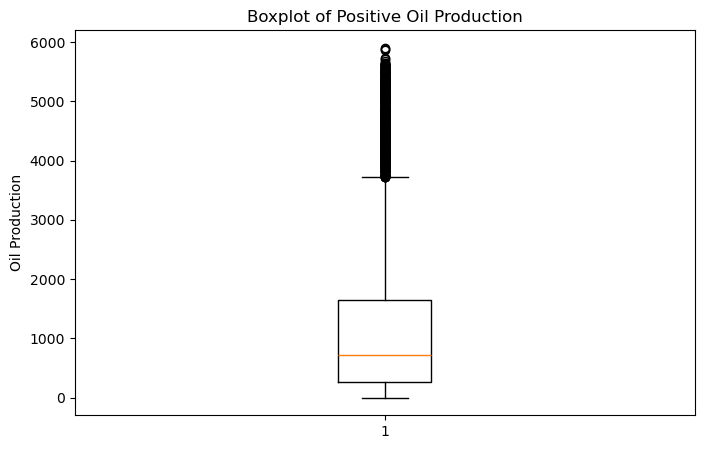

In [51]:
plt.figure(figsize=(8, 5))

plt.boxplot(oil_positive)

plt.ylabel("Oil Production")
plt.title("Boxplot of Positive Oil Production")

plt.show()

In [52]:
high_production = df_clean[
    df_clean["BORE_OIL_VOL"] > upper_bound
].sort_values(
    "BORE_OIL_VOL",
    ascending=False
)

high_production[
    ["DATEPRD", "NPD_WELL_BORE_NAME", "BORE_OIL_VOL"]
].head(20)

,DATEPRD,NPD_WELL_BORE_NAME,BORE_OIL_VOL
2240,2009-01-08,15/9-F-12,5901.84
2385,2009-06-03,15/9-F-12,5888.69
2242,2009-01-10,15/9-F-12,5869.78
2235,2009-01-03,15/9-F-12,5727.05
2243,2009-01-11,15/9-F-12,5716.64
2329,2009-04-07,15/9-F-12,5677.96
5548,2009-09-20,15/9-F-14,5644.37
2241,2009-01-09,15/9-F-12,5644.01
5364,2009-03-17,15/9-F-14,5634.32
2237,2009-01-05,15/9-F-12,5629.04


In [53]:
print("Number of high-production observations:", len(high_production))
print(
    "Percentage:",
    round(len(high_production) / len(oil_positive) * 100, 2),
    "%"
)

Number of high-production observations: 693
Percentage: 8.65 %


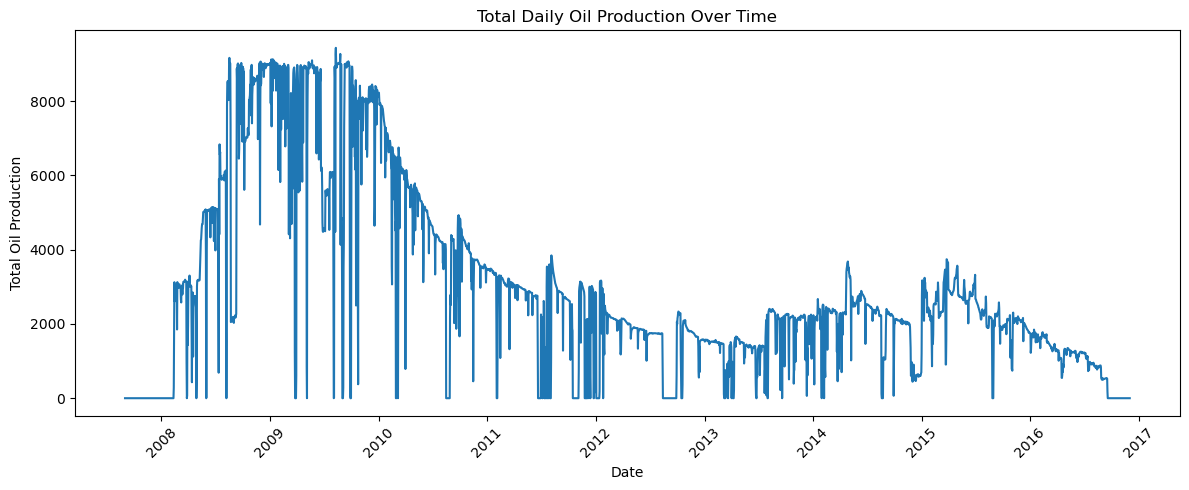

In [54]:
daily_oil = df_clean.groupby("DATEPRD")["BORE_OIL_VOL"].sum()

plt.figure(figsize=(12, 5))

plt.plot(daily_oil)

plt.xlabel("Date")
plt.ylabel("Total Oil Production")
plt.title("Total Daily Oil Production Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

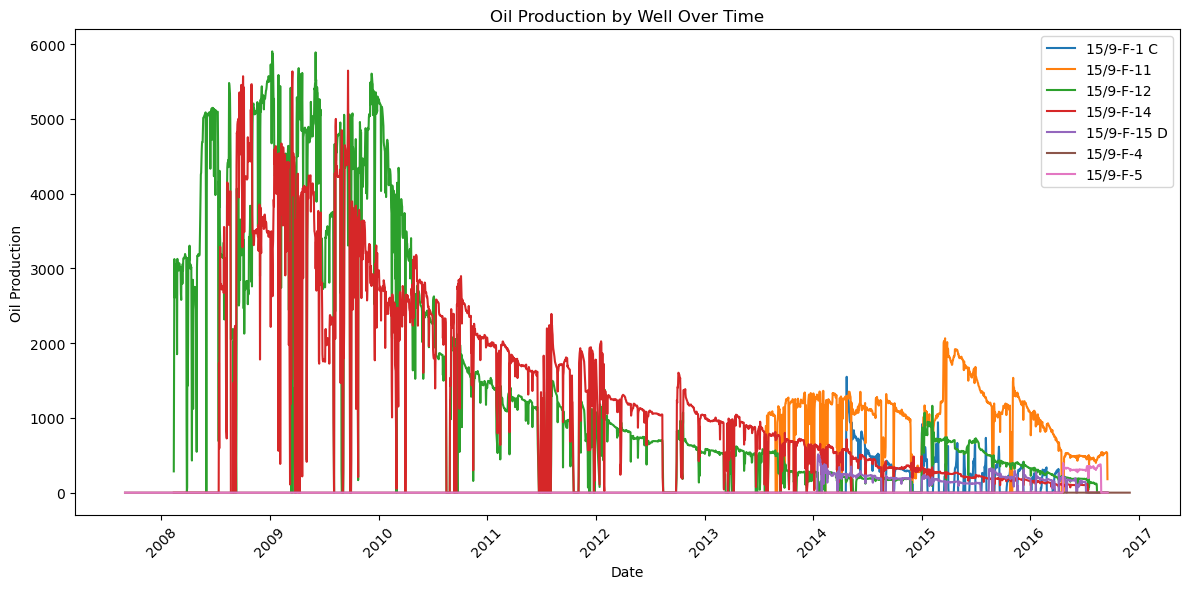

In [55]:
plt.figure(figsize=(12, 6))

for well, data in df_clean.groupby("NPD_WELL_BORE_NAME"):
    plt.plot(
        data["DATEPRD"],
        data["BORE_OIL_VOL"],
        label=well
    )

plt.xlabel("Date")
plt.ylabel("Oil Production")
plt.title("Oil Production by Well Over Time")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
cumulative_oil = (
    df_clean.groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"]
    .sum()
    .sort_values(ascending=False)
)

print(cumulative_oil)

NPD_WELL_BORE_NAME
15/9-F-12      4579609.55
15/9-F-14      3942233.39
15/9-F-11      1147849.10
15/9-F-1 C      177709.33
15/9-F-15 D     148518.56
15/9-F-5         41160.68
15/9-F-4             0.00
Name: BORE_OIL_VOL, dtype: float64


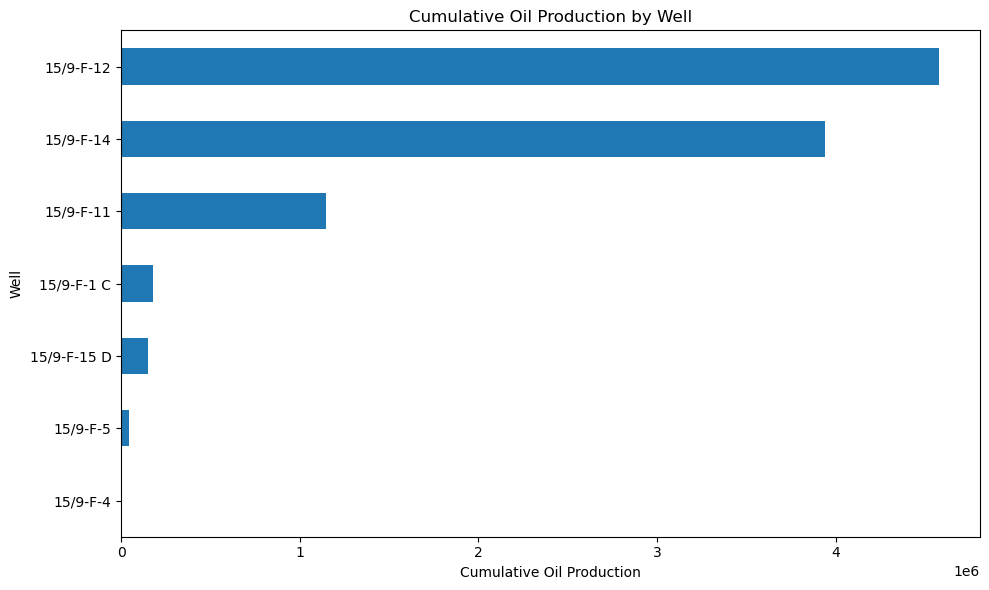

In [57]:
plt.figure(figsize=(10, 6))

cumulative_oil.sort_values().plot(kind="barh")

plt.xlabel("Cumulative Oil Production")
plt.ylabel("Well")
plt.title("Cumulative Oil Production by Well")

plt.tight_layout()
plt.show()

In [58]:
well_contribution = (
    df_clean.groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"]
    .sum()
    .sort_values(ascending=False)
)

well_contribution_pct = (
    well_contribution / well_contribution.sum() * 100
)

print(well_contribution_pct)

NPD_WELL_BORE_NAME
15/9-F-12      45.626908
15/9-F-14      39.276694
15/9-F-11      11.436085
15/9-F-1 C      1.770528
15/9-F-15 D     1.479699
15/9-F-5        0.410086
15/9-F-4        0.000000
Name: BORE_OIL_VOL, dtype: float64


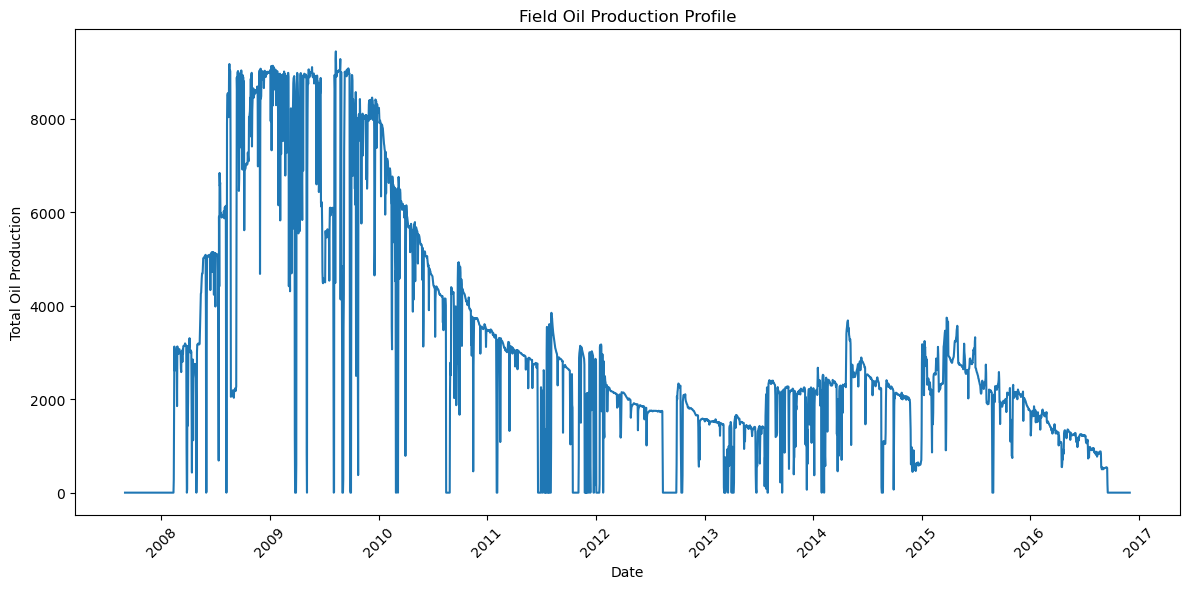

In [59]:
field_production = (
    df_clean.groupby("DATEPRD")["BORE_OIL_VOL"]
    .sum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    field_production.index,
    field_production.values
)

plt.xlabel("Date")
plt.ylabel("Total Oil Production")
plt.title("Field Oil Production Profile")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
df_clean["YEAR"] = df_clean["DATEPRD"].dt.year

yearly_production = (
    df_clean.groupby("YEAR")["BORE_OIL_VOL"]
    .sum()
)

print(yearly_production)

YEAR
2007          0.00
2008    1764375.15
2009    2684392.04
2010    1689902.55
2011     847965.40
2012     574206.33
2013     558012.53
2014     743107.49
2015     861749.06
2016     313370.06
Name: BORE_OIL_VOL, dtype: float64


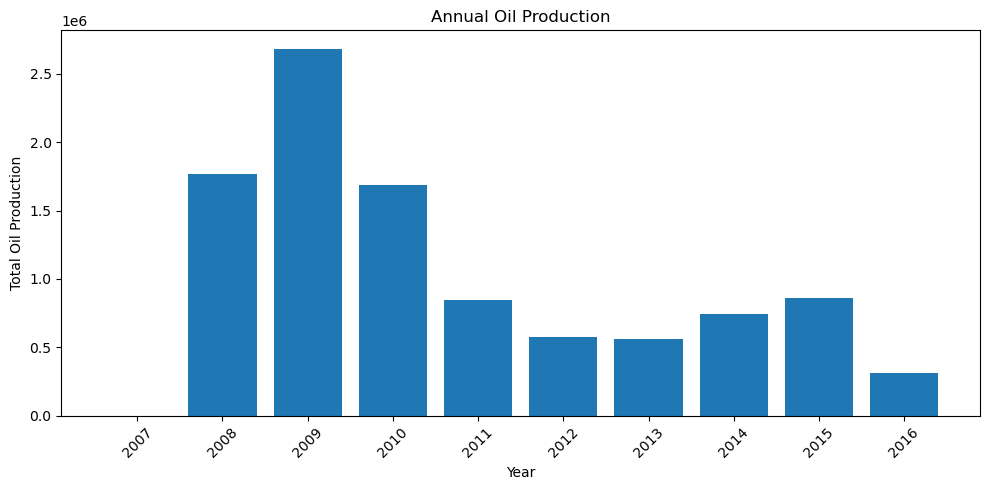

In [61]:
plt.figure(figsize=(10, 5))

plt.bar(
    yearly_production.index.astype(str),
    yearly_production.values
)

plt.xlabel("Year")
plt.ylabel("Total Oil Production")
plt.title("Annual Oil Production")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
numeric_cols = df_clean.select_dtypes(include="number").columns

corr = df_clean[numeric_cols].corr()

print(
    corr["BORE_OIL_VOL"]
    .sort_values(ascending=False)
)

BORE_OIL_VOL                1.000000
BORE_GAS_VOL                0.998789
DP_CHOKE_SIZE               0.444968
AVG_WHP_P                   0.430498
AVG_WHT_P                   0.382194
AVG_DOWNHOLE_TEMPERATURE    0.289819
AVG_DOWNHOLE_PRESSURE       0.248571
ON_STREAM_HRS               0.243562
BORE_WAT_VOL                0.166578
AVG_DP_TUBING               0.126964
AVG_CHOKE_SIZE_P            0.029671
AVG_ANNULUS_PRESS          -0.025095
BORE_WI_VOL                -0.091290
NPD_WELL_BORE_CODE         -0.155217
YEAR                       -0.361327
NPD_FIELD_CODE                   NaN
NPD_FACILITY_CODE                NaN
Name: BORE_OIL_VOL, dtype: float64


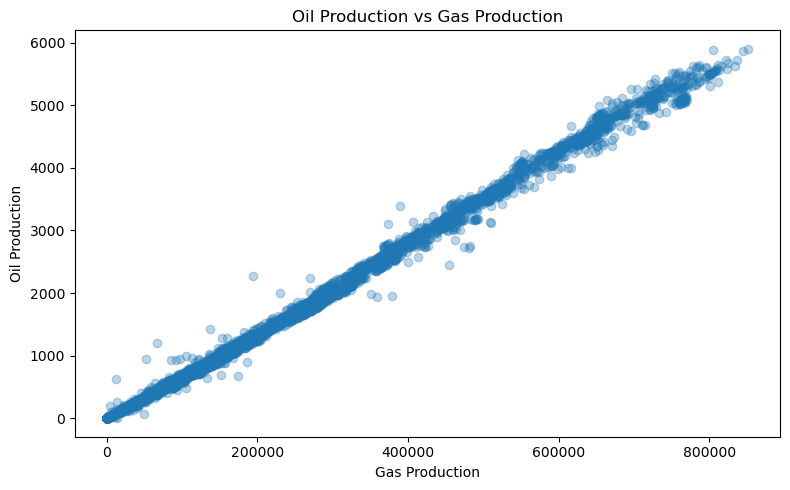

In [63]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["BORE_GAS_VOL"],
    df_clean["BORE_OIL_VOL"],
    alpha=0.3
)

plt.xlabel("Gas Production")
plt.ylabel("Oil Production")
plt.title("Oil Production vs Gas Production")

plt.tight_layout()
plt.show()

In [64]:
high_prod = df_clean[
    df_clean["BORE_OIL_VOL"] > df_clean["BORE_OIL_VOL"].quantile(0.95)
]

high_prod.groupby("NPD_WELL_BORE_NAME")["BORE_OIL_VOL"].count().sort_values(
    ascending=False
)

NPD_WELL_BORE_NAME
15/9-F-12    520
15/9-F-14    262
Name: BORE_OIL_VOL, dtype: int64

In [67]:
well_summary = df_clean.groupby("NPD_WELL_BORE_NAME").agg(
    First_Date=("DATEPRD", "min"),
    Last_Date=("DATEPRD", "max"),
    Records=("DATEPRD", "count"),
    Total_Oil=("BORE_OIL_VOL", "sum"),
    Max_Oil=("BORE_OIL_VOL", "max"),
    Mean_Oil=("BORE_OIL_VOL", "mean")
)

print(well_summary)

                   First_Date  Last_Date  Records   Total_Oil  Max_Oil  \
NPD_WELL_BORE_NAME                                                       
15/9-F-1 C         2014-04-07 2016-04-21      746   177709.33  1549.81   
15/9-F-11          2013-07-08 2016-09-17     1165  1147849.10  2064.61   
15/9-F-12          2008-02-12 2016-09-17     3056  4579609.55  5901.84   
15/9-F-14          2008-02-12 2016-09-17     3056  3942233.39  5644.37   
15/9-F-15 D        2014-01-12 2016-09-17      978   148518.56   513.12   
15/9-F-4           2007-09-01 2016-12-01     3327        0.00     0.00   
15/9-F-5           2007-09-01 2016-09-18     3306    41160.68   396.80   

                       Mean_Oil  
NPD_WELL_BORE_NAME               
15/9-F-1 C           238.216260  
15/9-F-11            985.278197  
15/9-F-12           1498.563334  
15/9-F-14           1289.997837  
15/9-F-15 D          151.859468  
15/9-F-4               0.000000  
15/9-F-5              12.450296  


In [75]:
production_2013 = yearly_production.loc[2013]
production_2015 = yearly_production.loc[2015]

recovery_pct = (
    (production_2015 - production_2013)
    / production_2013
    * 100
)

print(f"2013 production: {production_2013:,.2f}")
print(f"2015 production: {production_2015:,.2f}")
print(f"Recovery: {recovery_pct:.2f}%")

2013 production: 558,012.53
2015 production: 861,749.06
Recovery: 54.43%


In [76]:
numeric_cols = df_clean.select_dtypes(include="number").columns

oil_corr = (
    df_clean[numeric_cols]
    .corr()["BORE_OIL_VOL"]
    .sort_values(ascending=False)
)

print(oil_corr)

BORE_OIL_VOL                1.000000
BORE_GAS_VOL                0.998789
DP_CHOKE_SIZE               0.444968
AVG_WHP_P                   0.430498
AVG_WHT_P                   0.382194
AVG_DOWNHOLE_TEMPERATURE    0.289819
AVG_DOWNHOLE_PRESSURE       0.248571
ON_STREAM_HRS               0.243562
BORE_WAT_VOL                0.166578
AVG_DP_TUBING               0.126964
AVG_CHOKE_SIZE_P            0.029671
AVG_ANNULUS_PRESS          -0.025095
BORE_WI_VOL                -0.091290
NPD_WELL_BORE_CODE         -0.155217
YEAR                       -0.361327
NPD_FIELD_CODE                   NaN
NPD_FACILITY_CODE                NaN
Name: BORE_OIL_VOL, dtype: float64


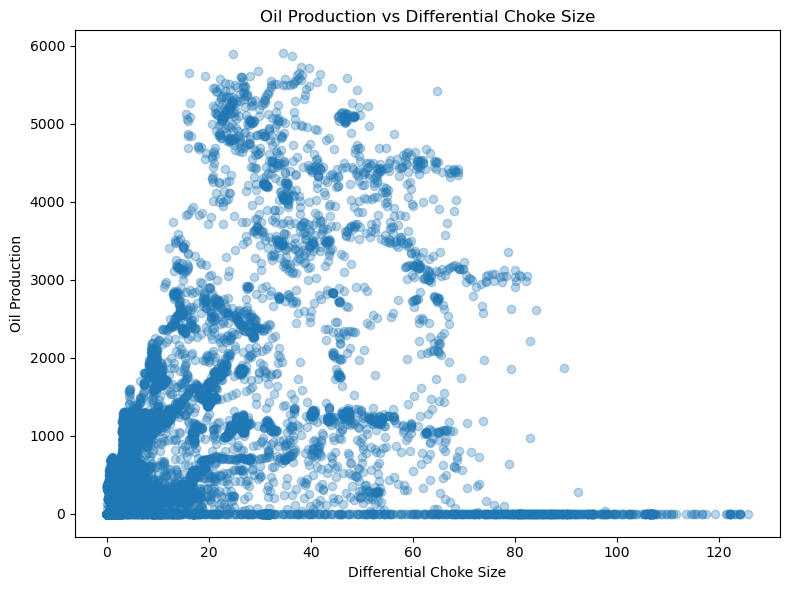

In [78]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clean["DP_CHOKE_SIZE"],
    df_clean["BORE_OIL_VOL"],
    alpha=0.3
)

plt.xlabel("Differential Choke Size")
plt.ylabel("Oil Production")
plt.title("Oil Production vs Differential Choke Size")

plt.tight_layout()
plt.show()

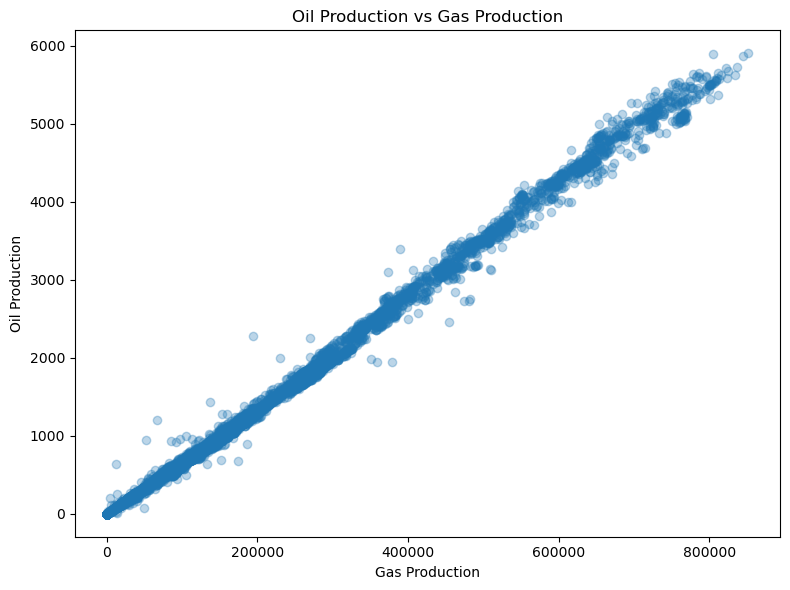

In [80]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clean["BORE_GAS_VOL"],
    df_clean["BORE_OIL_VOL"],
    alpha=0.3
)

plt.xlabel("Gas Production")
plt.ylabel("Oil Production")
plt.title("Oil Production vs Gas Production")

plt.tight_layout()
plt.show()

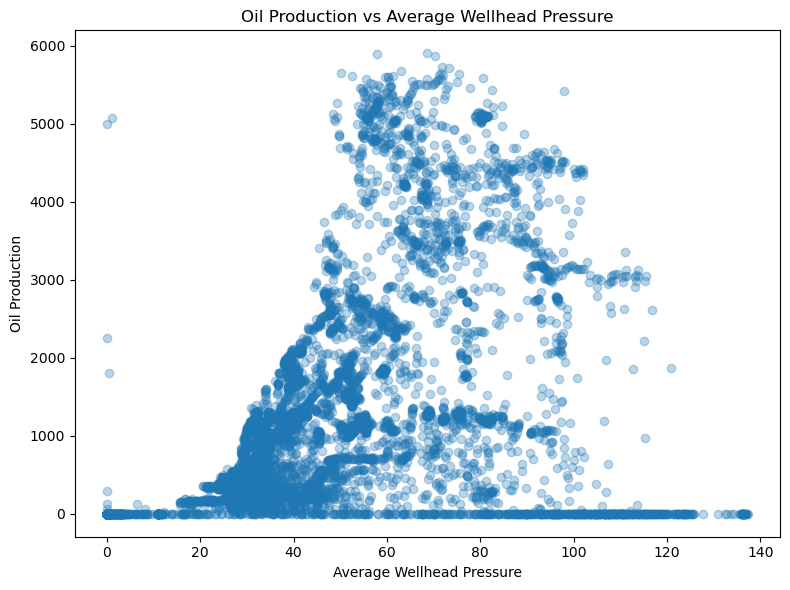

In [79]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_clean["AVG_WHP_P"],
    df_clean["BORE_OIL_VOL"],
    alpha=0.3
)

plt.xlabel("Average Wellhead Pressure")
plt.ylabel("Oil Production")
plt.title("Oil Production vs Average Wellhead Pressure")

plt.tight_layout()
plt.show()

In [81]:
df_clean["GOR"] = (
    df_clean["BORE_GAS_VOL"] / df_clean["BORE_OIL_VOL"]
)

gor = df_clean.loc[
    df_clean["BORE_OIL_VOL"] > 0,
    "GOR"
]

print(gor.describe())

count    8008.000000
mean      151.960542
std        16.449967
min        18.536118
25%       145.826418
50%       151.429372
75%       156.810801
max      1110.185309
Name: GOR, dtype: float64


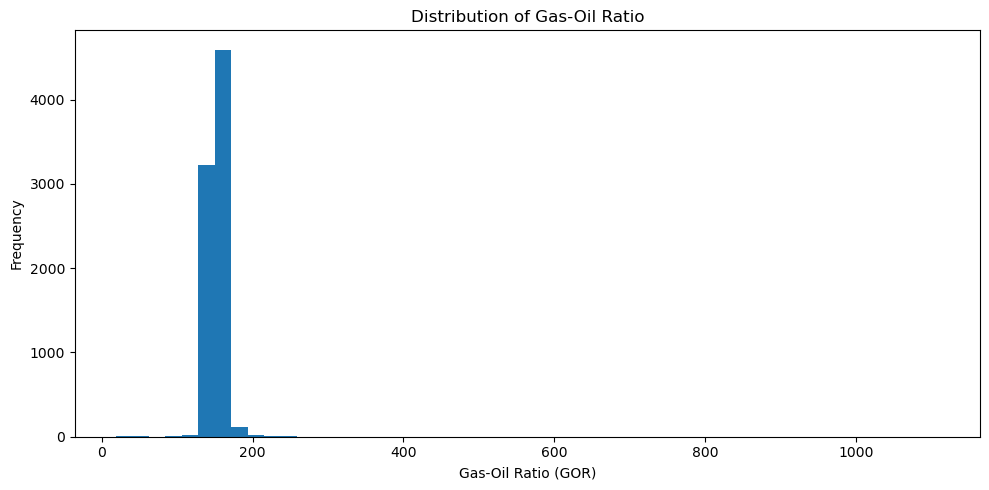

In [82]:
plt.figure(figsize=(10, 5))

plt.hist(gor, bins=50)

plt.xlabel("Gas-Oil Ratio (GOR)")
plt.ylabel("Frequency")
plt.title("Distribution of Gas-Oil Ratio")

plt.tight_layout()
plt.show()

In [83]:
high_gor = df_clean[df_clean["GOR"] > 200]

print("Number of high-GOR observations:", len(high_gor))
print("Percentage:", len(high_gor) / len(df_clean) * 100)

print(
    high_gor[
        ["DATEPRD", "NPD_WELL_BORE_NAME",
         "BORE_OIL_VOL", "BORE_GAS_VOL", "GOR"]
    ].sort_values("GOR", ascending=False).head(10)
)

Number of high-GOR observations: 27
Percentage: 0.17270052449788922
        DATEPRD NPD_WELL_BORE_NAME  BORE_OIL_VOL  BORE_GAS_VOL          GOR
2827 2010-08-28          15/9-F-12          0.00        535.16          inf
6339 2011-12-26          15/9-F-14          0.00         56.38          inf
3283 2011-12-26          15/9-F-12          0.00          7.09          inf
2446 2009-08-04          15/9-F-12         11.98      13300.02  1110.185309
1956 2008-03-28          15/9-F-12         73.44      48936.44   666.345861
2020 2008-06-01          15/9-F-12         22.94      11729.20   511.299041
6186 2011-07-09          15/9-F-14         19.48       6610.68   339.357290
4248 2014-09-30          15/9-F-12        137.42      35158.14   255.844419
7304 2014-09-30          15/9-F-14        157.75      40359.14   255.842409
1192 2014-09-30          15/9-F-11        680.46     174084.77   255.833951


In [84]:
zero_oil = df_clean[df_clean["BORE_OIL_VOL"] == 0]

print("Zero-oil observations:", len(zero_oil))
print("Percentage:", len(zero_oil) / len(df_clean) * 100)

print("\nZero-oil observations by well:")
print(
    zero_oil["NPD_WELL_BORE_NAME"]
    .value_counts()
)

Zero-oil observations: 7626
Percentage: 48.778303697070484

Zero-oil observations by well:
NPD_WELL_BORE_NAME
15/9-F-4       3327
15/9-F-5       3177
15/9-F-14       333
15/9-F-1 C      316
15/9-F-12       220
15/9-F-15 D     211
15/9-F-11        42
Name: count, dtype: int64


In [85]:
zero_oil_by_well = (
    df_clean.groupby("NPD_WELL_BORE_NAME")
    .agg(
        Total_Records=("BORE_OIL_VOL", "size"),
        Zero_Oil=("BORE_OIL_VOL", lambda x: (x == 0).sum())
    )
)

zero_oil_by_well["Zero_Oil_%"] = (
    zero_oil_by_well["Zero_Oil"]
    / zero_oil_by_well["Total_Records"]
    * 100
)

print(zero_oil_by_well.sort_values("Zero_Oil_%", ascending=False))

                    Total_Records  Zero_Oil  Zero_Oil_%
NPD_WELL_BORE_NAME                                     
15/9-F-4                     3327      3327  100.000000
15/9-F-5                     3306      3177   96.098004
15/9-F-1 C                    746       316   42.359249
15/9-F-15 D                   978       211   21.574642
15/9-F-14                    3056       333   10.896597
15/9-F-12                    3056       220    7.198953
15/9-F-11                    1165        42    3.605150


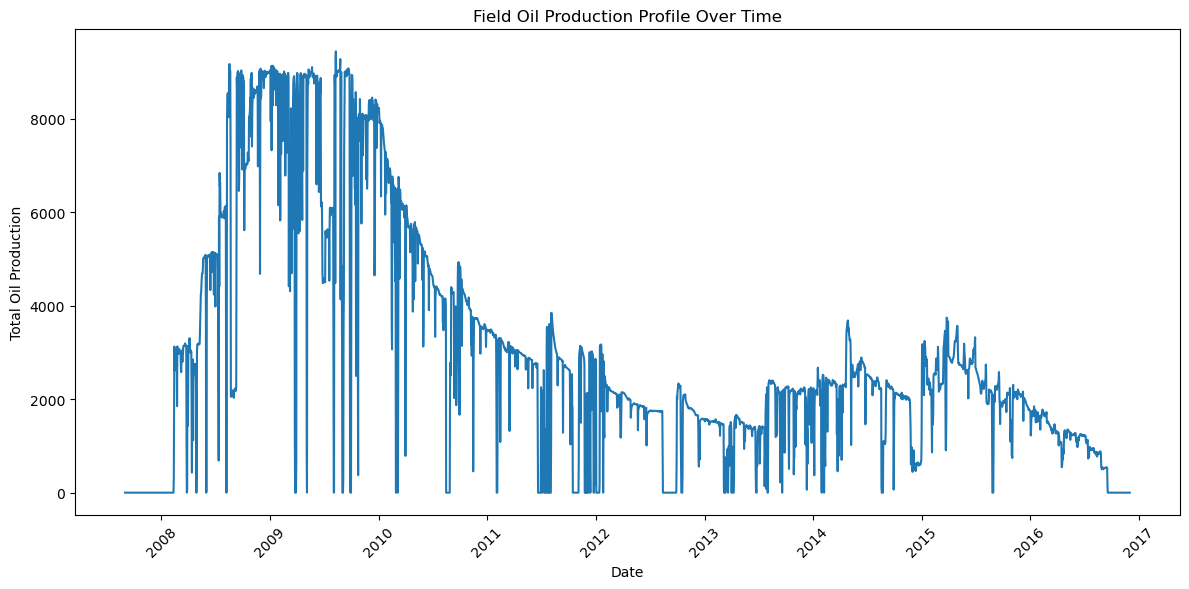

In [86]:
plt.figure(figsize=(12, 6))

plt.plot(
    field_production.index,
    field_production.values
)

plt.xlabel("Date")
plt.ylabel("Total Oil Production")
plt.title("Field Oil Production Profile Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

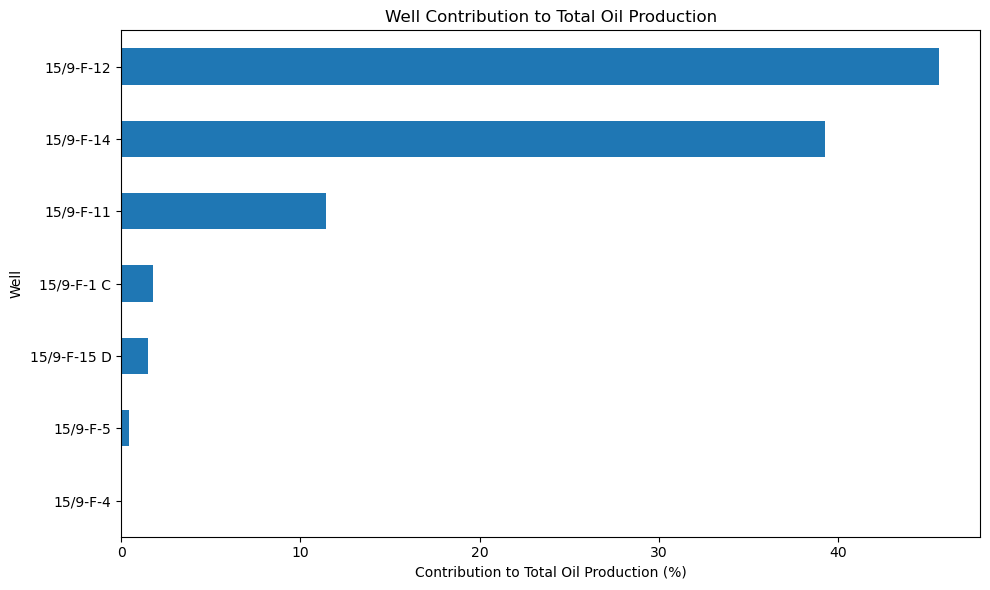

In [87]:
plt.figure(figsize=(10, 6))

well_contribution_pct.sort_values().plot(kind="barh")

plt.xlabel("Contribution to Total Oil Production (%)")
plt.ylabel("Well")
plt.title("Well Contribution to Total Oil Production")

plt.tight_layout()
plt.show()

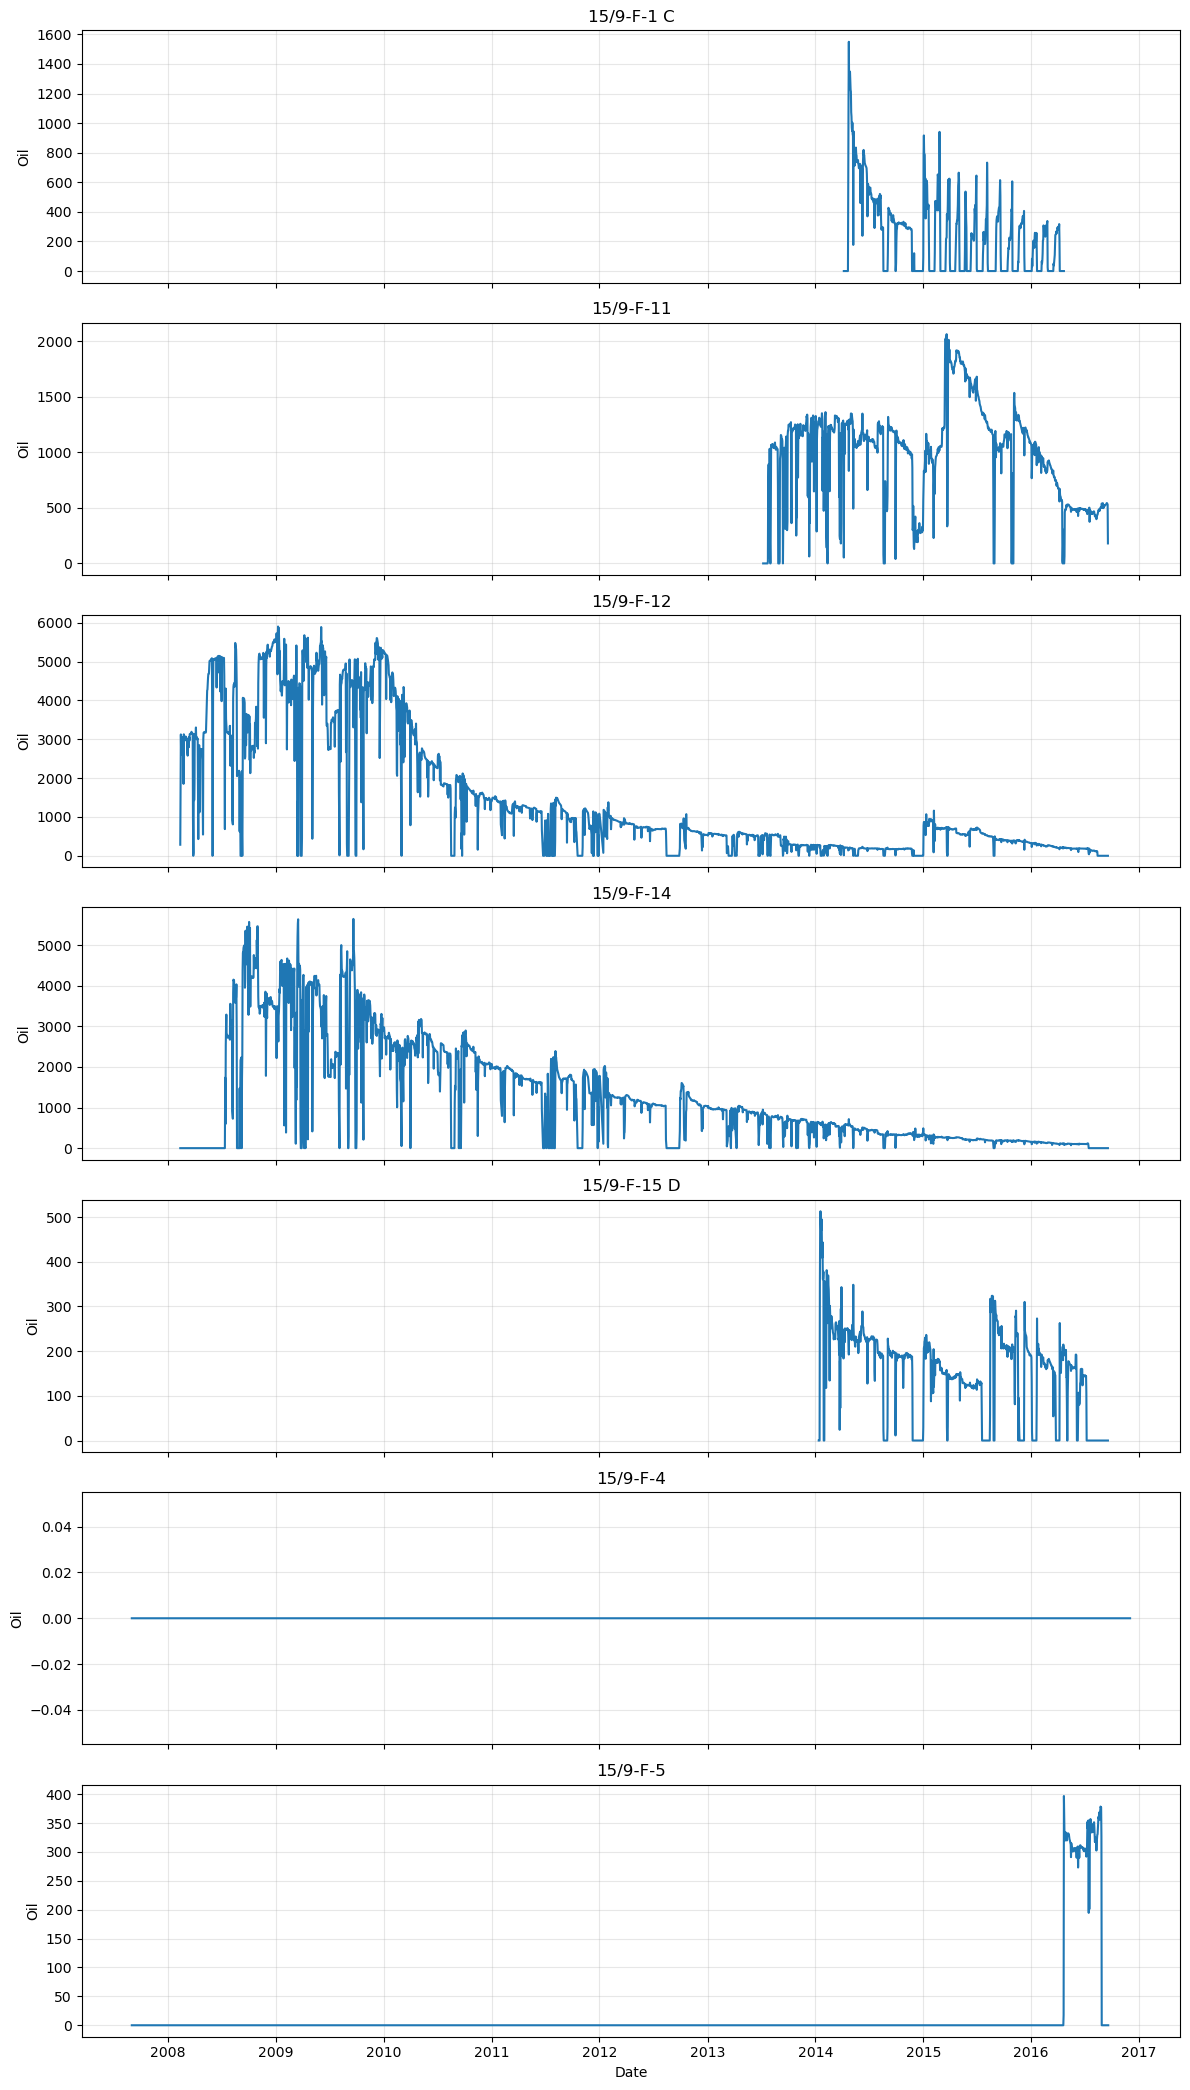

In [88]:
wells = df_clean["NPD_WELL_BORE_NAME"].unique()

fig, axes = plt.subplots(
    len(wells),
    1,
    figsize=(12, 3 * len(wells)),
    sharex=True
)

for ax, well in zip(axes, wells):

    data = df_clean[
        df_clean["NPD_WELL_BORE_NAME"] == well
    ]

    ax.plot(
        data["DATEPRD"],
        data["BORE_OIL_VOL"]
    )

    ax.set_ylabel("Oil")
    ax.set_title(well)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()